$$\text{Double Pendulum Simulation}$$
$\text{The inspiration of this code is from a video of 3Blue1Brown's, Fourier Series video.}$
$\text{I definetly can't make the animation used in the video, but certainly can make an extremely small animation by using just two rods.}$
$\text{Double pendulum is special because it is a really simple example of a chaotic system. Because both the rods, affects the final position.}$
$\text{which in turn makes it trace paths which can not easily be predicted.}$


In [482]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from matplotlib import animation

In [483]:
t, g = smp.symbols('t g')
m1, m2 = smp.symbols('m1 m2')
L1, L2 = smp.symbols('L1 L2')

In [484]:
the1, the2 = smp.symbols(r'\theta_1, \theta_2', cls=smp.Function)

In [485]:
the1 = the1(t)
the2 = the2(t)

In [486]:
the1_d = smp.diff(the1, t)
the2_d = smp.diff(the2, t)
the1_dd = smp.diff(the1_d, t)
the2_dd = smp.diff(the2_d, t)

In [487]:
x1 = L1 * smp.sin(the1)
y1 = - L1 * smp.cos(the1)
x2 = L1 * smp.sin(the1) + L2 * smp.sin(the2)
y2 = - L1 * smp.cos(the1) - L2 * smp.cos(the2)

In [488]:
T1 = (1/2) * m1 * (smp.diff(x1, t)**2 + smp.diff(y1, t)**2)
T2 = (1/2) * m2 * (smp.diff(x2, t)**2 + smp.diff(y2, t)**2)
T = T1 + T2

V1 = m1 * g * y1
V2 = m2 * g * y2
V = V1 + V2

L = T - V

In [489]:
T

0.5*m1*(L1**2*sin(\theta_1(t))**2*Derivative(\theta_1(t), t)**2 + L1**2*cos(\theta_1(t))**2*Derivative(\theta_1(t), t)**2) + 0.5*m2*((L1*sin(\theta_1(t))*Derivative(\theta_1(t), t) + L2*sin(\theta_2(t))*Derivative(\theta_2(t), t))**2 + (L1*cos(\theta_1(t))*Derivative(\theta_1(t), t) + L2*cos(\theta_2(t))*Derivative(\theta_2(t), t))**2)

In [490]:
V

-L1*g*m1*cos(\theta_1(t)) + g*m2*(-L1*cos(\theta_1(t)) - L2*cos(\theta_2(t)))

In [491]:
L

L1*g*m1*cos(\theta_1(t)) - g*m2*(-L1*cos(\theta_1(t)) - L2*cos(\theta_2(t))) + 0.5*m1*(L1**2*sin(\theta_1(t))**2*Derivative(\theta_1(t), t)**2 + L1**2*cos(\theta_1(t))**2*Derivative(\theta_1(t), t)**2) + 0.5*m2*((L1*sin(\theta_1(t))*Derivative(\theta_1(t), t) + L2*sin(\theta_2(t))*Derivative(\theta_2(t), t))**2 + (L1*cos(\theta_1(t))*Derivative(\theta_1(t), t) + L2*cos(\theta_2(t))*Derivative(\theta_2(t), t))**2)

$Langrange's\ Equation:$
$$\frac{\partial L}{\partial \theta_1} - \frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\theta_1}} \right) = 0$$
$$\frac{\partial L}{\partial \theta_2} - \frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\theta_2}} \right) = 0$$

In [492]:
LE1 = smp.diff(L, the1) - smp.diff(smp.diff(L, the1_d), t).simplify()
LE2 = smp.diff(L, the2) - smp.diff(smp.diff(L, the2_d), t).simplify()

In [493]:
LE1

-L1*g*m1*sin(\theta_1(t)) - L1*g*m2*sin(\theta_1(t)) - 1.0*L1*(L1*m1*Derivative(\theta_1(t), (t, 2)) + L1*m2*Derivative(\theta_1(t), (t, 2)) - L2*m2*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t) + L2*m2*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_2(t), t)**2 + L2*m2*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_2(t), (t, 2))) + 0.5*m2*(2*L1*(L1*sin(\theta_1(t))*Derivative(\theta_1(t), t) + L2*sin(\theta_2(t))*Derivative(\theta_2(t), t))*cos(\theta_1(t))*Derivative(\theta_1(t), t) - 2*L1*(L1*cos(\theta_1(t))*Derivative(\theta_1(t), t) + L2*cos(\theta_2(t))*Derivative(\theta_2(t), t))*sin(\theta_1(t))*Derivative(\theta_1(t), t))

In [494]:
LE2

-L2*g*m2*sin(\theta_2(t)) - 1.0*L2*m2*(-L1*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)**2 + L1*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t) + L1*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), (t, 2)) + L2*Derivative(\theta_2(t), (t, 2))) + 0.5*m2*(2*L2*(L1*sin(\theta_1(t))*Derivative(\theta_1(t), t) + L2*sin(\theta_2(t))*Derivative(\theta_2(t), t))*cos(\theta_2(t))*Derivative(\theta_2(t), t) - 2*L2*(L1*cos(\theta_1(t))*Derivative(\theta_1(t), t) + L2*cos(\theta_2(t))*Derivative(\theta_2(t), t))*sin(\theta_2(t))*Derivative(\theta_2(t), t))

In [495]:
sols = smp.solve([LE1, LE2], (the1_dd, the2_dd), simplify=False, rational=False)

In [496]:
# It is just double differential of theta1 with respect to time
sols[the1_dd]

-1.0*L1*m2*sin(\theta_1(t) - \theta_2(t))*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)**2/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L1*m2) + 1.0*L1*m2*sin(\theta_1(t) - \theta_2(t))*cos(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L1*m2) - 1.0*L1*m2*sin(\theta_1(t))*cos(\theta_1(t) - \theta_2(t))*cos(\theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L1*m2) + 1.0*L1*m2*sin(\theta_2(t))*cos(\theta_1(t) - \theta_2(t))*cos(\theta_1(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L1*m2) + 1.0*L2*m2*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L1*m2) - 1.0*L2*m2*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta

In [497]:
# It is just double differential of theta2 with respect to time
sols[the2_dd]

1.0*L1*m1*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)**2/(1.0*L2*m1 - 1.0*L2*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L2*m2) - 1.0*L1*m1*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L2*m1 - 1.0*L2*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L2*m2) + 1.0*L1*m1*sin(\theta_1(t))*cos(\theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L2*m1 - 1.0*L2*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L2*m2) - 1.0*L1*m1*sin(\theta_2(t))*cos(\theta_1(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L2*m1 - 1.0*L2*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L2*m2) + 1.0*L1*m2*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)**2/(1.0*L2*m1 - 1.0*L2*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L2*m2) - 1.0*L1*m2*sin(\theta_1(t) - \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L2*m1 - 1.0*L2*m2*cos(\theta_1(t) - \theta_2(t))**2 + 1.0*L2*m2) + 1.0*L1*m2*sin(\theta_1(t))*cos(\theta_2(

$$\text{Let } z_1 = \frac{d \theta_1}{dt} \text{ and } z_2 = \frac{d \theta_2}{dt}$$
$$\text{then } \frac{dz_1}{dt} = \frac{d^2 \theta_1}{dt^2} \text{ and } \frac{dz_2}{dt} = \frac{d^2 \theta_2}{dt^2}$$

In [498]:
# Now these are just numerical functions of the earlier declared symbolic functions
dz1dt_f = smp.lambdify((t, g, m1, m2, L1, L2, the1, the2, the1_d, the2_d), sols[the1_dd])
dz2dt_f = smp.lambdify((t, g, m1, m2, L1, L2, the1, the2, the1_d, the2_d), sols[the2_dd])
dthe1dt_f = smp.lambdify(the1_d, the1_d)
dthe2dt_f = smp.lambdify(the2_d, the2_d)

Now $\vec{S} = (\theta_1, z_1, \theta_2, z_2)$

In [499]:
def dSdt(S, t, g, m1, m2, L1, L2):
    the1, z1, the2, z2 = S
    return [
        dthe1dt_f(z1),
        dz1dt_f(t, g, m1, m2, L1, L2, the1, the2, z1, z2),
        dthe2dt_f(z2),
        dz2dt_f(t, g, m1, m2, L1, L2, the1, the2, z1, z2),
    ]

In [500]:
t = np.linspace(0, 40, 1001)
g = 9.81
m1 = 1.5
m2 = 2
L1 = 1
L2 = 2
ans = odeint(dSdt, y0 = [1, -3, -1, 5], t = t, args=(g, m1, m2, L1, L2))

In [501]:
the1 = ans.T[0]
the2 = ans.T[2]

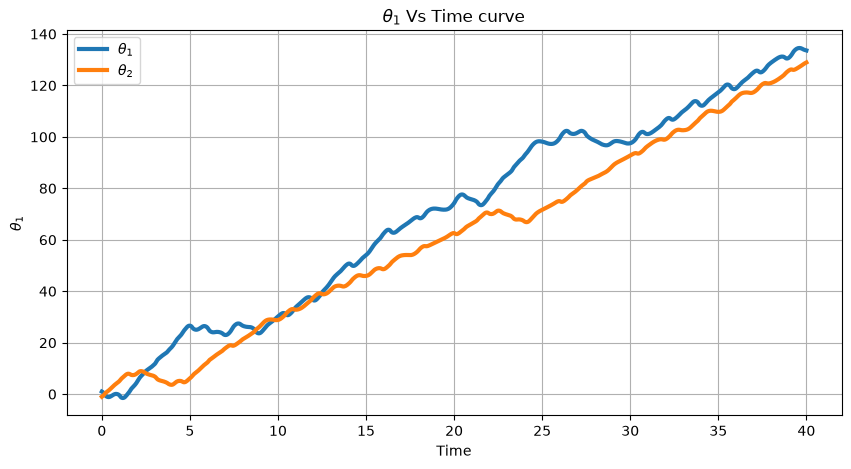

In [502]:
plt.figure(figsize=(10, 5))
plt.title(r'$\theta_1$ Vs Time curve')
plt.xlabel('Time')
plt.ylabel(r'$\theta_1$')
plt.plot(t, the1, lw=3, label=r'$\theta_1$')
plt.plot(t, the2, lw=3, label=r'$\theta_2$')
plt.legend()
plt.grid()

$\text{Every time wherever you see a spike, the respective pendulum's rotation direction changes}$

In [503]:
def get_x1y1x2y2(t, the1, the2, L1, L2):
    return (
        L1 * np.sin(the1),
        - L1 * np.cos(the1),
        L1 * np.sin(the1) + L2 * np.sin(the2),
        - L1 * np.cos(the1) - L2 * np.cos(the2)
    )

x1, y1, x2, y2 = get_x1y1x2y2(t, ans.T[0], ans.T[2], L1, L2)

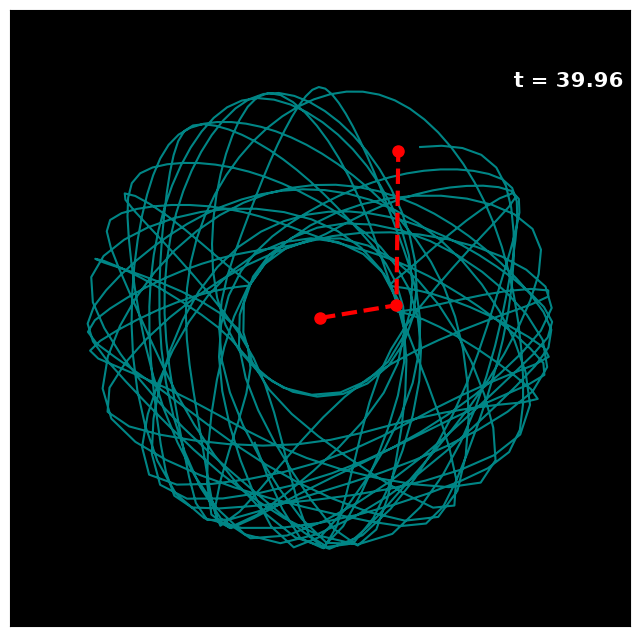

In [504]:
def animate(i):
    ln1.set_data([0, x1[i], x2[i]], [0, y1[i], y2[i]])
    ln2.set_data(x2[:i], y2[:i])
    time_text.set_text('t = {:.2f}'.format(i/25))
    return ln1, ln2, time_text

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_facecolor('k')
ax.get_xaxis().set_ticks([])
ax.get_yaxis().set_ticks([])
ln1, = plt.plot([], [], 'ro--', lw=3, markersize=8, zorder=2)
ln2, = plt.plot([], [], 'c-', lw=1.5, alpha=0.7, zorder=1)
time_text = ax.text(2.5, 3, 'time', fontsize=15, fontweight='bold', color='white')

ax.set_ylim(-4, 4)
ax.set_xlim(-4, 4)

ani = animation.FuncAnimation(fig, animate, frames=1000, interval=50, blit=True)
ani.save('dblpen.gif', writer='pillow', fps=25)

In [506]:
# Do see the animation file saved as media\dblpen.gif